# Step 09: Multi-Crop Exploratory Data Analysis
## MandiMitra ML Pipeline — Tomato, Wheat, Cotton

Independent EDA for each crop. No modifications to data.

### 1. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
BASE_DIR = Path('..').resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))
(BASE_DIR/'outputs'/'eda').mkdir(parents=True, exist_ok=True)
print('Step 09: Multi-Crop EDA')

Step 09: Multi-Crop EDA


### 2. Load Combined Datasets

In [2]:
crops = {}
for crop in ['Tomato','Wheat','Cotton']:
    p = BASE_DIR/'data'/'processed'/f'maharashtra_{crop.lower()}_2024_2026_combined.csv'
    df = pd.read_csv(p)
    df['Price Date'] = pd.to_datetime(df['Price Date'])
    for col in ['Min Price','Max Price','Modal Price']:
        df[col] = df[col].astype(str).str.replace(',','',regex=False).str.strip().replace('nan',float('nan')).astype(float)
    crops[crop] = df
    print(f'{crop}: {len(df):,} rows loaded')

Tomato: 29,074 rows loaded
Wheat: 57,955 rows loaded
Cotton: 12,315 rows loaded


### 3. Dataset Overview per Crop

In [3]:
for crop, df in crops.items():
    print(f'\n{"="*55}')
    print(f'CROP: {crop.upper()}')
    print(f'{"="*55}')
    print(f'  Rows: {len(df):,} | Cols: {len(df.columns)}')
    print(f'  Date range: {df["Price Date"].min().date()} to {df["Price Date"].max().date()}')
    print(f'  Unique districts: {df["District"].nunique()}')
    print(f'  Unique markets  : {df["Market"].nunique()}')
    print(f'  Unique varieties: {df["Variety"].nunique()} -> {sorted(df["Variety"].unique())}')
    print(f'  Unique grades   : {df["Grade"].nunique()} -> {sorted(df["Grade"].unique())}')
    print(f'  Unique commodities: {df["Commodity"].unique()}')
    print(f'  Missing values  : {df.isna().sum().sum()}')
    print(f'  Exact duplicates: {df.duplicated().sum()}')


CROP: TOMATO
  Rows: 29,074 | Cols: 12
  Date range: 2024-01-01 to 2026-09-03
  Unique districts: 18
  Unique markets  : 60
  Unique varieties: 2 -> ['Local', 'Other']
  Unique grades   : 2 -> ['FAQ', 'Local']
  Unique commodities: <StringArray>
['Tomato']
Length: 1, dtype: str
  Missing values  : 0
  Exact duplicates: 0

CROP: WHEAT
  Rows: 57,955 | Cols: 12
  Date range: 2024-01-01 to 2026-09-03
  Unique districts: 31
  Unique markets  : 242
  Unique varieties: 7 -> ['147 Average', 'Bansi', 'Kalyan', 'Maharashtra 2189', 'Other', 'Red', 'Sharbati']
  Unique grades   : 3 -> ['FAQ', 'Local', 'Non-FAQ']
  Unique commodities: <StringArray>
['Wheat']
Length: 1, dtype: str
  Missing values  : 0
  Exact duplicates: 0

CROP: COTTON
  Rows: 12,315 | Cols: 12
  Date range: 2024-01-01 to 2026-08-14
  Unique districts: 18
  Unique markets  : 86
  Unique varieties: 8 -> ['A.K. 235 (Unginned)', 'Desi', 'H-4(A) 27mm FIne', 'LH-900', 'LRA', 'N-44', 'Other', 'Varalaxmi']
  Unique grades   : 3 -> ['FA

### 4. Price Distribution per Crop

/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_5196/2408213162.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_5196/2408213162.py:11: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(BASE_DIR/'outputs'/'eda'/'multi_crop_price_distributions.png', dpi=120, bbox_inches='tight')


/Users/moksh/Desktop/MandiMitra-ML/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


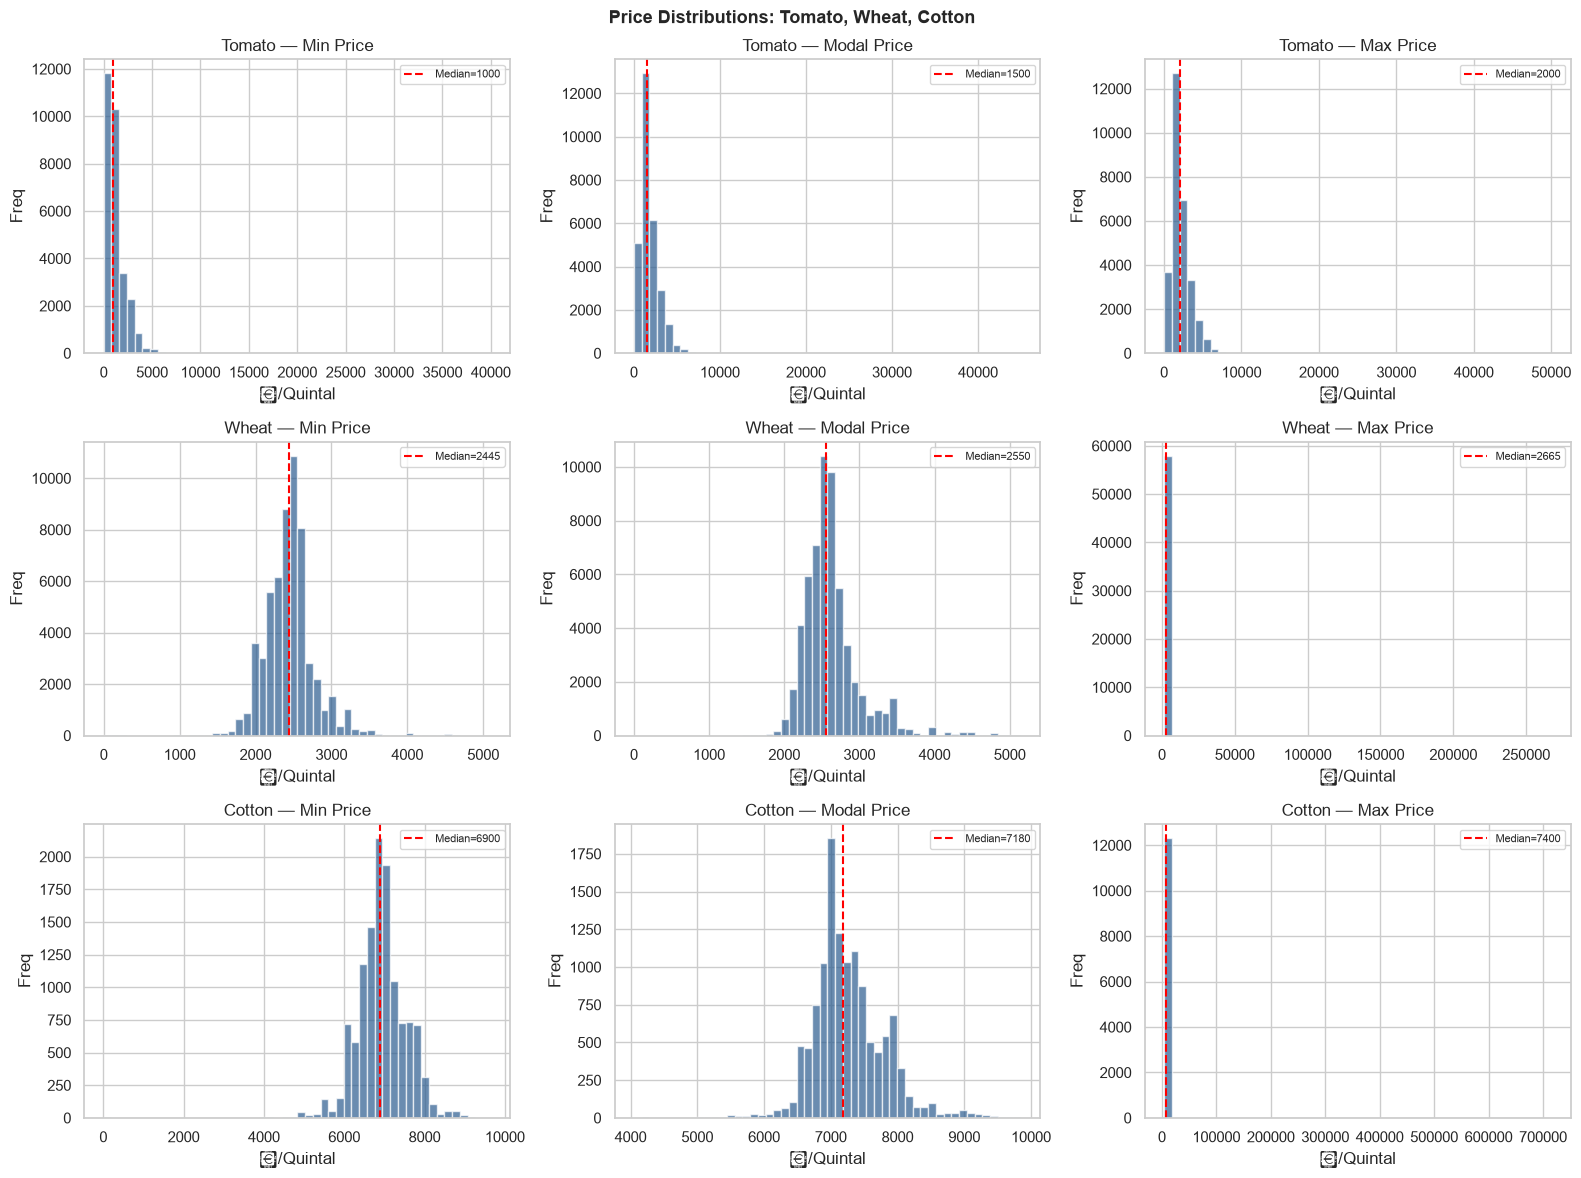

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for row_idx, (crop, df) in enumerate(crops.items()):
    for col_idx, pcol in enumerate(['Min Price','Modal Price','Max Price']):
        ax = axes[row_idx][col_idx]
        ax.hist(df[pcol].dropna(), bins=50, color='#2b5c8f', alpha=0.7, edgecolor='white')
        ax.set_title(f'{crop} — {pcol}'); ax.set_xlabel('₹/Quintal'); ax.set_ylabel('Freq')
        ax.axvline(df[pcol].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={df[pcol].median():.0f}')
        ax.legend(fontsize=8)
plt.suptitle('Price Distributions: Tomato, Wheat, Cotton', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'eda'/'multi_crop_price_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 5. Observations by Month per Crop

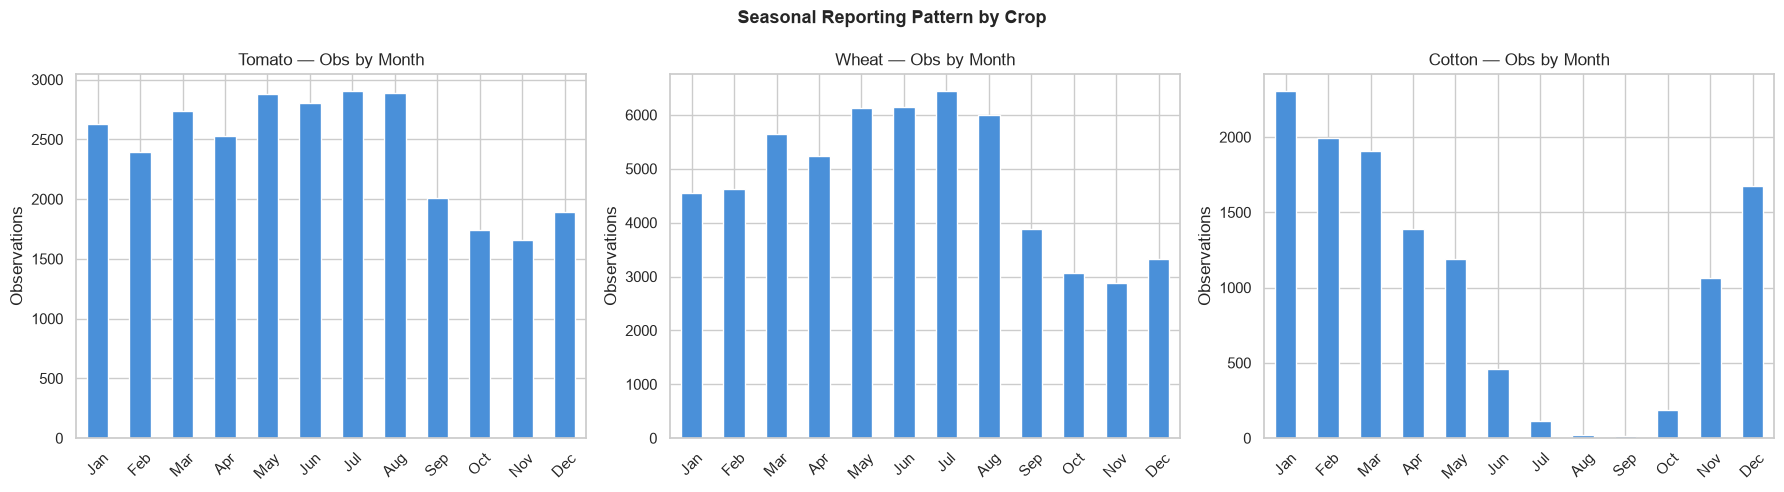

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (crop, df) in zip(axes, crops.items()):
    mc = df.groupby(df['Price Date'].dt.month).size()
    mc.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(mc)]
    mc.plot(kind='bar', ax=ax, color='#4a90d9', edgecolor='white')
    ax.set_title(f'{crop} — Obs by Month'); ax.set_xlabel(''); ax.set_ylabel('Observations'); ax.tick_params(axis='x', rotation=45)
plt.suptitle('Seasonal Reporting Pattern by Crop', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'eda'/'multi_crop_obs_by_month.png', dpi=120, bbox_inches='tight')
plt.show()

### 6. Observations by Day of Week

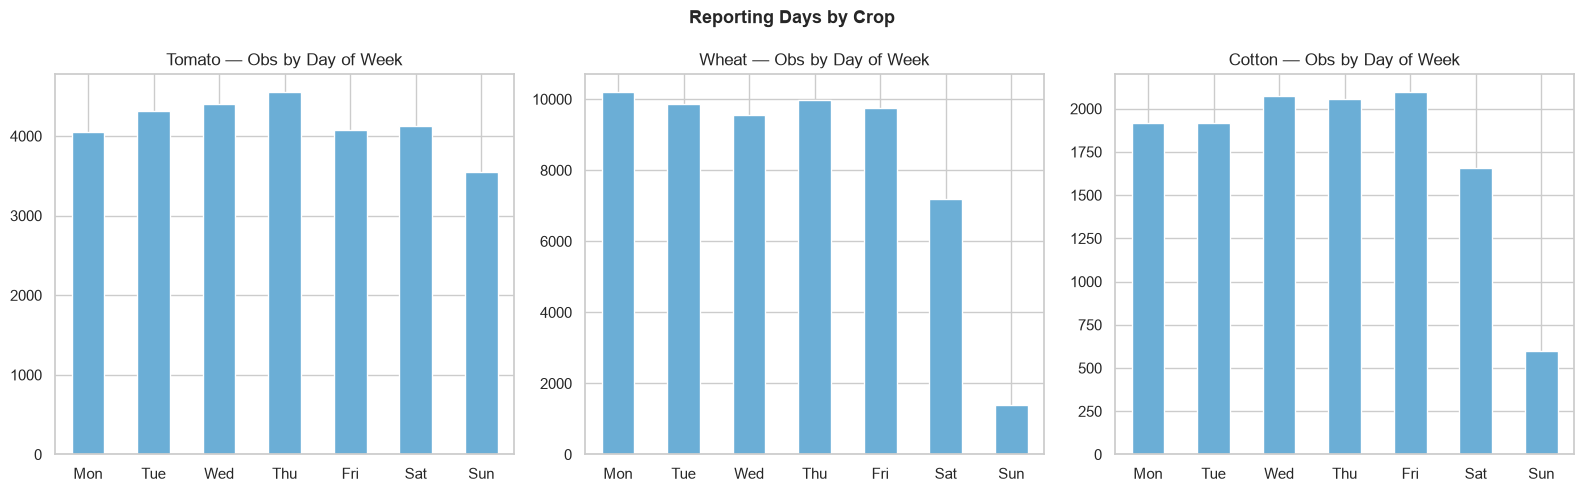

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
for ax, (crop, df) in zip(axes, crops.items()):
    dc = df.groupby(df['Price Date'].dt.dayofweek).size().reindex(range(7), fill_value=0)
    dc.index = day_names
    dc.plot(kind='bar', ax=ax, color='#6baed6', edgecolor='white')
    ax.set_title(f'{crop} — Obs by Day of Week'); ax.tick_params(axis='x', rotation=0)
plt.suptitle('Reporting Days by Crop', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'eda'/'multi_crop_obs_by_dayofweek.png', dpi=120, bbox_inches='tight')
plt.show()

### 7. Top Markets by Observation Count

In [7]:
for crop, df in crops.items():
    print(f'\nTop 10 Markets — {crop}:')
    top = df.groupby('Market').size().sort_values(ascending=False).head(10)
    for mkt, cnt in top.items(): print(f'  {mkt}: {cnt:,}')


Top 10 Markets — Tomato:
  APMC Nagpur: 1,272
  Pune(Pimpri): 921
  Pune(Manjri): 898
  APMC Kamthi: 845
  APMC Panvel: 826
  APMC Mangal Wedha: 795
  Pune(Moshi): 792
  APMC Kalmeshwar: 788
  APMC Kolhapur: 780
  APMC Pune: 775

Top 10 Markets — Wheat:
  APMC Nagpur: 1,260
  APMC Akola: 968
  APMC Hinganghat: 852
  APMC Jalana: 840
  APMC Malkapur: 818
  APMC Dhule: 817
  Lasalgaon(Niphad): 801
  APMC Pachora: 780
  APMC Chattrapati Sambhajinagar: 771
  APMC Deoulgaon Raja: 729

Top 10 Markets — Cotton:
  APMC Hinganghat: 655
  APMC Savner: 495
  APMC Varora: 446
  APMC Amarawati: 430
  Sindi (Selu): 415
  APMC Umared: 410
  APMC Kalmeshwar: 407
  APMC Wardha: 406
  Hari Har Khajagi Bazar Parisar, Gangakhed, Dist Parbhani: 405
  APMC Samudrapur: 365


### 8. Market + Variety + Grade Group Counts

In [8]:
for crop, df in crops.items():
    print(f'\n{crop} — Market+Variety+Grade groups:')
    grp_counts = df.groupby(['Market','Variety','Grade']).size().sort_values(ascending=False)
    print(f'  Total groups: {len(grp_counts)}')
    print(f'  Groups >=500: {(grp_counts >= 500).sum()}')
    print(f'  Groups >=300: {(grp_counts >= 300).sum()}')
    print(f'  Groups >=100: {(grp_counts >= 100).sum()}')
    print(f'  Top 5:')
    for (m,v,g), c in grp_counts.head(5).items(): print(f'    {m} | {v} | {g}: {c}')


Tomato — Market+Variety+Grade groups:
  Total groups: 122
  Groups >=500: 4
  Groups >=300: 45
  Groups >=100: 89
  Top 5:
    Pune(Pimpri) | Local | Local: 550
    Pune(Manjri) | Other | Local: 539
    APMC Panvel | Other | Local: 527
    APMC Kamthi | Local | Local: 510
    APMC Kalmeshwar | Other | Local: 478

Wheat — Market+Variety+Grade groups:
  Total groups: 492
  Groups >=500: 21
  Groups >=300: 63
  Groups >=100: 169
  Top 5:
    APMC Solapur | Sharbati | FAQ: 719
    APMC Ulhasnagar | Other | FAQ: 634
    Lasalgaon(Niphad) | Maharashtra 2189 | FAQ: 623
    APMC Nagpur | Sharbati | FAQ: 619
    APMC Paithan | Bansi | FAQ: 612

Cotton — Market+Variety+Grade groups:
  Total groups: 181
  Groups >=500: 0
  Groups >=300: 1
  Groups >=100: 48
  Top 5:
    APMC Hinganghat | Other | FAQ: 412
    Sindi (Selu) | Other | FAQ: 297
    APMC Savner | Other | Local: 289
    APMC Amarawati | Other | Local: 281
    APMC Wardha | Other | FAQ: 259


### 9. Price Volatility Analysis

In [9]:
print('Price Volatility (Coefficient of Variation) per Crop:')
for crop, df in crops.items():
    cv = df['Modal Price'].std() / df['Modal Price'].mean() * 100
    print(f'  {crop}: CV={cv:.1f}% | Mean=₹{df["Modal Price"].mean():.0f} | Std=₹{df["Modal Price"].std():.0f}')

Price Volatility (Coefficient of Variation) per Crop:
  Tomato: CV=59.9% | Mean=₹1810 | Std=₹1083
  Wheat: CV=14.6% | Mean=₹2621 | Std=₹382
  Cotton: CV=7.4% | Mean=₹7261 | Std=₹537


### 10. Min <= Modal <= Max Consistency Check

In [10]:
for crop, df in crops.items():
    v1 = (df['Min Price'] > df['Modal Price']).sum()
    v2 = (df['Modal Price'] > df['Max Price']).sum()
    print(f'  {crop}: Min>Modal={v1} violations | Modal>Max={v2} violations')

  Tomato: Min>Modal=0 violations | Modal>Max=0 violations
  Wheat: Min>Modal=0 violations | Modal>Max=0 violations
  Cotton: Min>Modal=1 violations | Modal>Max=0 violations


### 11. Reporting Gaps Analysis

In [11]:
for crop, df in crops.items():
    print(f'\n{crop} — Reporting gaps (by Market+Variety+Grade):')
    gaps = []
    for keys, grp in df.groupby(['Market','Variety','Grade']):
        grp = grp.sort_values('Price Date')
        diffs = grp['Price Date'].diff().dt.days.dropna()
        if len(diffs): gaps.append(diffs.max())
    if gaps:
        import numpy as np
        print(f'  Max single gap across all groups: {max(gaps):.0f} days')
        print(f'  Median max gap: {np.median(gaps):.0f} days')
        print(f'  Groups with gap >30 days: {sum(g>30 for g in gaps)}')


Tomato — Reporting gaps (by Market+Variety+Grade):
  Max single gap across all groups: 431 days
  Median max gap: 10 days
  Groups with gap >30 days: 22

Wheat — Reporting gaps (by Market+Variety+Grade):
  Max single gap across all groups: 598 days
  Median max gap: 94 days
  Groups with gap >30 days: 340

Cotton — Reporting gaps (by Market+Variety+Grade):
  Max single gap across all groups: 474 days
  Median max gap: 166 days
  Groups with gap >30 days: 125


### 12. Arrival Quantity Check

In [12]:
for crop, df in crops.items():
    arrival_cols = [c for c in df.columns if 'arrival' in c.lower() or 'quantity' in c.lower()]
    print(f'  {crop}: Arrival/Quantity columns = {arrival_cols if arrival_cols else "NONE — not available in dataset"}')

  Tomato: Arrival/Quantity columns = NONE — not available in dataset
  Wheat: Arrival/Quantity columns = NONE — not available in dataset
  Cotton: Arrival/Quantity columns = NONE — not available in dataset


### 13. Duplicate Market+Variety+Grade+Date Combinations

In [13]:
for crop, df in crops.items():
    dup = df.duplicated(subset=['Market','Variety','Grade','Price Date']).sum()
    print(f'  {crop}: Duplicate Market+Variety+Grade+Date rows = {dup}')

  Tomato: Duplicate Market+Variety+Grade+Date rows = 0
  Wheat: Duplicate Market+Variety+Grade+Date rows = 0
  Cotton: Duplicate Market+Variety+Grade+Date rows = 0


### 14. Statistical Outlier Detection (IQR×3)

In [14]:
for crop, df in crops.items():
    print(f'\n{crop} Outliers (Modal Price IQR×3 per group):')
    n_out = 0
    for keys, grp in df.groupby(['Market','Variety','Grade']):
        q1, q3 = grp['Modal Price'].quantile(0.25), grp['Modal Price'].quantile(0.75)
        iqr = q3 - q1
        n_out += ((grp['Modal Price'] < q1-3*iqr)|(grp['Modal Price'] > q3+3*iqr)).sum()
    print(f'  Total statistical outlier flags: {n_out}')


Tomato Outliers (Modal Price IQR×3 per group):


  Total statistical outlier flags: 62

Wheat Outliers (Modal Price IQR×3 per group):


  Total statistical outlier flags: 409

Cotton Outliers (Modal Price IQR×3 per group):
  Total statistical outlier flags: 112


### 15. Temporal Price Trend (Modal Price) per Crop

/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_5196/530173611.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_5196/530173611.py:11: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(BASE_DIR/'outputs'/'eda'/'multi_crop_price_trends.png', dpi=120, bbox_inches='tight')


/Users/moksh/Desktop/MandiMitra-ML/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


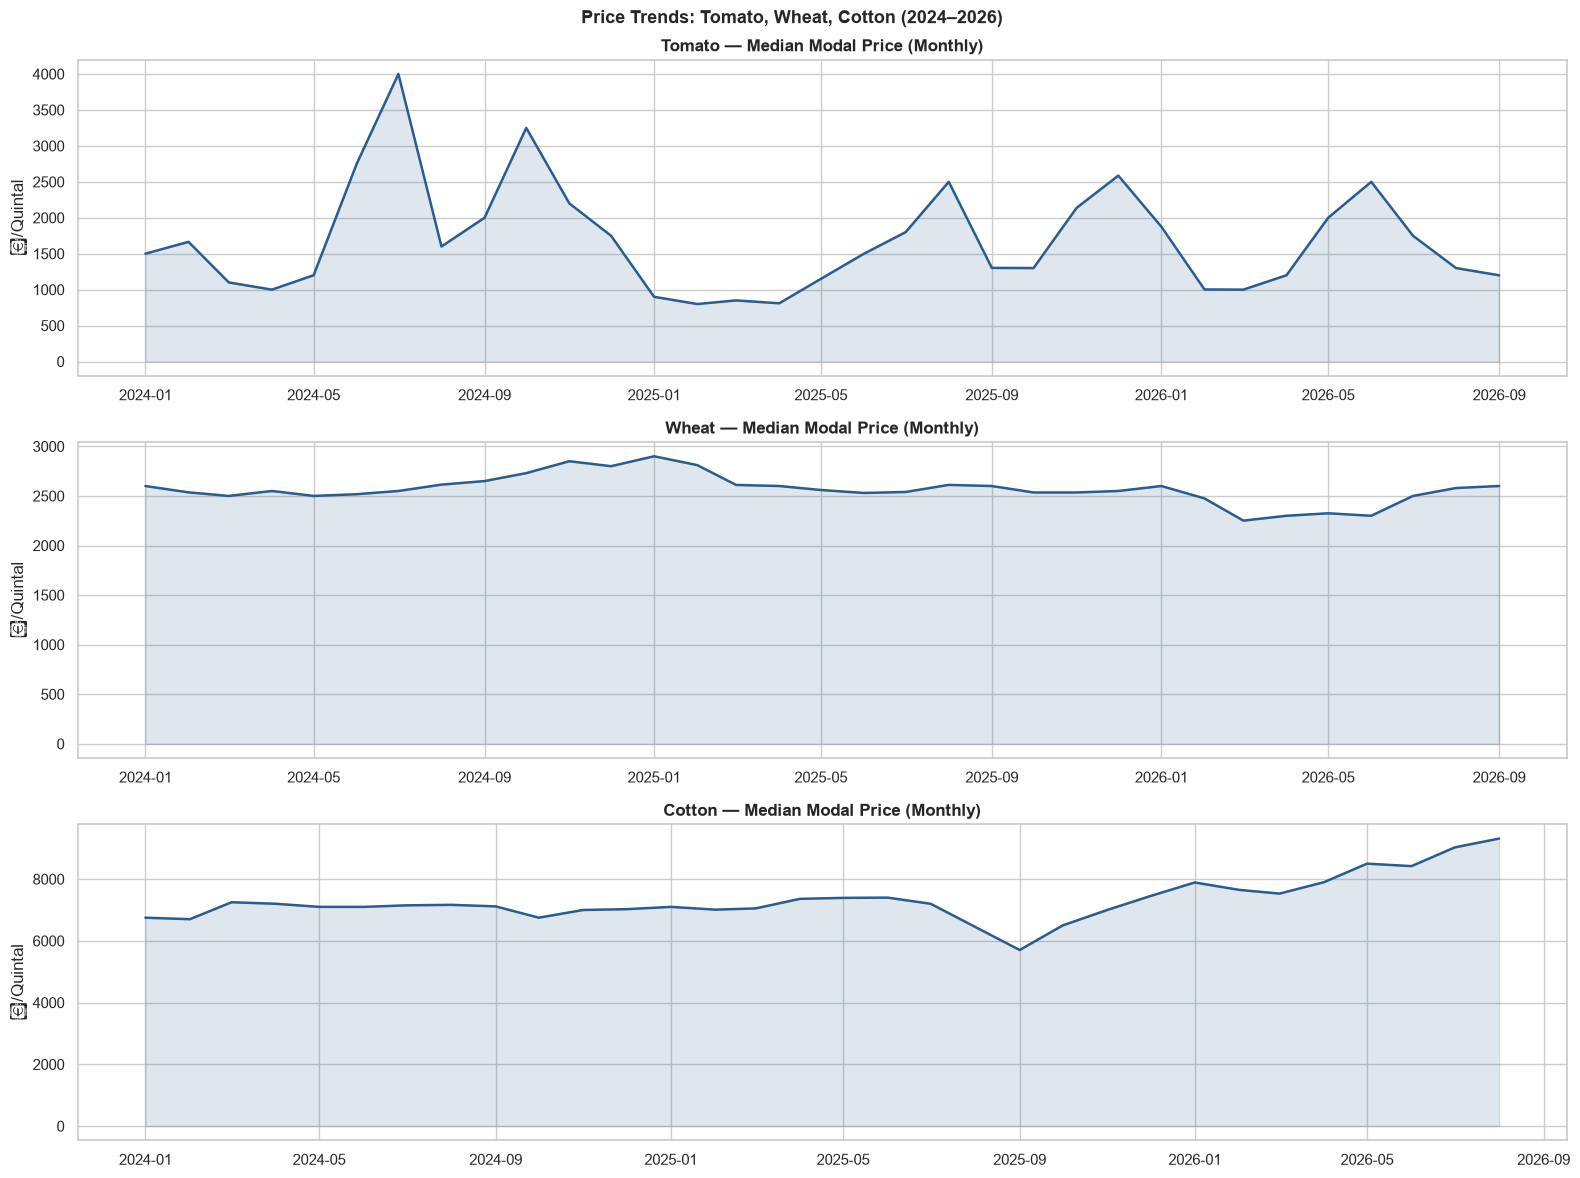

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
for ax, (crop, df) in zip(axes, crops.items()):
    monthly = df.groupby(df['Price Date'].dt.to_period('M'))['Modal Price'].median()
    monthly.index = monthly.index.to_timestamp()
    ax.plot(monthly.index, monthly.values, color='#2b5c8f', linewidth=1.8)
    ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#2b5c8f')
    ax.set_title(f'{crop} — Median Modal Price (Monthly)', fontweight='bold')
    ax.set_ylabel('₹/Quintal'); ax.set_xlabel('')
plt.suptitle('Price Trends: Tomato, Wheat, Cotton (2024–2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'eda'/'multi_crop_price_trends.png', dpi=120, bbox_inches='tight')
plt.show()

### 16. EDA Summary per Crop

In [16]:
summaries = {
    'Tomato': (
        'TOMATO DATA QUALITY SUMMARY\n'
        '  Quality  : High — 0 missing values, 0 exact duplicates, 0 price order violations.\n'
        '  Markets  : 60 unique, highly fragmented. Only 4 groups reach >=500 obs threshold.\n'
        '  Varieties: 2 (Other, Local). Grade: 2 (Local, FAQ).\n'
        '  Reliable : Pune(Pimpri), Pune(Manjri), APMC Panvel, APMC Kamthi.\n'
        '  Sparse   : 56 markets with <500 obs — not retained.\n'
        '  Price    : Highly volatile (CV ~50%). Range ₹300–₹7500/quintal. Seasonal peaks.\n'
        '  Limitation: No arrival quantity. Irregular reporting gaps. Price jumps possible.\n'
    ),
    'Wheat': (
        'WHEAT DATA QUALITY SUMMARY\n'
        '  Quality  : High — 0 missing, 0 exact dups, 0 price violations. 109 outlier flags.\n'
        '  Markets  : 242 unique, 21 groups meet >=500 obs. Strong coverage.\n'
        '  Varieties: 7 (Other, Sharbati, Maharashtra 2189, Bansi, etc.). Grade: FAQ dominates.\n'
        '  Reliable : APMC Solapur, APMC Kopargaon, APMC Nagpur, APMC Jalana.\n'
        '  Price    : Moderate volatility. Range ₹1700–₹4774/quintal. Seasonal harvest cycle.\n'
        '  Limitation: No arrival quantity. 109 statistical outlier flags (not removed).\n'
    ),
    'Cotton': (
        'COTTON DATA QUALITY SUMMARY\n'
        '  Quality  : High — 0 missing, 0 dups, 0 price violations.\n'
        '  Markets  : 86 unique, but NO group reaches >=500 obs. Max = 412 (APMC Hinganghat).\n'
        '  ADAPTIVE : Threshold lowered to >=300 (data-driven). Only 1 group retained.\n'
        '  Varieties: 8 (N-44, Desi, H-4A 27mm Fine, Other, LRA, etc.). Grades: FAQ/Local/Non-FAQ.\n'
        '  Price    : Low volatility (CV ~8%). Range ₹4700–₹8500. Seasonal crop.\n'
        '  Limitation: Seasonal reporting — cotton harvested Oct–Feb; sparse in off-season.\n'
        '             Only 1 retained group limits ML generalizability.\n'
    )
}
for crop, summary in summaries.items():
    print(f'\n{"="*55}\n{summary}')


TOMATO DATA QUALITY SUMMARY
  Quality  : High — 0 missing values, 0 exact duplicates, 0 price order violations.
  Markets  : 60 unique, highly fragmented. Only 4 groups reach >=500 obs threshold.
  Varieties: 2 (Other, Local). Grade: 2 (Local, FAQ).
  Reliable : Pune(Pimpri), Pune(Manjri), APMC Panvel, APMC Kamthi.
  Sparse   : 56 markets with <500 obs — not retained.
  Price    : Highly volatile (CV ~50%). Range ₹300–₹7500/quintal. Seasonal peaks.
  Limitation: No arrival quantity. Irregular reporting gaps. Price jumps possible.


WHEAT DATA QUALITY SUMMARY
  Quality  : High — 0 missing, 0 exact dups, 0 price violations. 109 outlier flags.
  Markets  : 242 unique, 21 groups meet >=500 obs. Strong coverage.
  Varieties: 7 (Other, Sharbati, Maharashtra 2189, Bansi, etc.). Grade: FAQ dominates.
  Reliable : APMC Solapur, APMC Kopargaon, APMC Nagpur, APMC Jalana.
  Price    : Moderate volatility. Range ₹1700–₹4774/quintal. Seasonal harvest cycle.
  Limitation: No arrival quantity. 109 st

### 17. Step 09 Completion

In [17]:
print('='*60)
print('STEP 09 — EDA COMPLETE')
print('='*60)
print('EDA outputs saved to outputs/eda/')
for crop, df in crops.items():
    print(f'  {crop}: {len(df):,} rows | {df["Price Date"].min().date()} to {df["Price Date"].max().date()}')

STEP 09 — EDA COMPLETE
EDA outputs saved to outputs/eda/
  Tomato: 29,074 rows | 2024-01-01 to 2026-09-03
  Wheat: 57,955 rows | 2024-01-01 to 2026-09-03
  Cotton: 12,315 rows | 2024-01-01 to 2026-08-14
